In [1]:
import pandas as pd
import pandapower as pp
import pandapower.networks as nw
import pandapower.topology as top
import networkx as nx
import numpy as np


In [2]:
net = nw.case30()

# Convert Pandapower to Graph. multi=False merges parallel lines
# to avoid the MultiGraph error in cycle basis finding.
G = top.create_nxgraph(net, multi=False)

# Get sorted lists to ensure matrix columns/rows are ordered predictably
nodes = sorted(list(G.nodes()))
edges = sorted(list(G.edges())) # Edges are natively stored as (u,v) where u < v

num_nodes = len(nodes)
num_edges = len(edges)

# --- 1. ORIENTED NODE-TO-EDGE INCIDENCE MATRIX (M_NE) ---
# Definition from Image: Leaves Node = +1, Arrives at Node = -1
print("Building Oriented Node-Edge Matrix...")

M_NE = np.zeros((num_nodes, num_edges), dtype=int)

# Create a node lookup map (node_id -> matrix_row_index)
node_idx_map = {node: i for i, node in enumerate(nodes)}

# Fill the matrix
for e_idx, edge in enumerate(edges):
    # For edge (u, v): u is the tail (from_bus), v is the head (to_bus)
    # The native ordering of edges (u < v) defines the reference direction.
    u = edge[0] # reference FROM bus
    v = edge[1] # reference TO bus
    
    u_idx = node_idx_map[u]
    v_idx = node_idx_map[v]
    
    M_NE[u_idx, e_idx] = 1   # Leaves u
    M_NE[v_idx, e_idx] = -1  # Arrives at v

print(f"M_NE Shape: {M_NE.shape}")


# --- 2. FIND FUNDAMENTAL CYCLE BASIS ---
print("\nFinding Fundamental Cycle Basis...")
cycles = nx.cycle_basis(G)
num_cycles = len(cycles)
print(f"Number of cycles: {num_cycles}")


# --- 3. ORIENTED EDGE-TO-CYCLE INCIDENCE MATRIX (M_EC) ---
# Definition from Image: Loop in reference direction = +1, anti-parallel = -1
print("\nBuilding Oriented Edge-Cycle Matrix...")

M_EC = np.zeros((num_edges, num_cycles), dtype=int)

# Create a fast lookup map for our edges (edge_tuple -> matrix_col_index)
edge_idx_map = { (u, v): i for i, (u, v) in enumerate(edges) }

for c_idx, loop in enumerate(cycles):
    # A cycle is a list of nodes, e.g., [1, 2, 3]
    # We create the traversal paths: (1,2), (2,3), (3,1)
    for i in range(len(loop)):
        curr_node = loop[i]
        next_node = loop[(i + 1) % len(loop)]
        
        # Check traversal direction against the original edge list
        
        # If traversal (curr->next) matches original edge (u->v)
        if (curr_node, next_node) in edge_idx_map:
            e_idx = edge_idx_map[(curr_node, next_node)]
            M_EC[e_idx, c_idx] = 1 # Traverse Forward (+1)
            
        # If traversal (curr->next) is anti-parallel (v->u) to original edge (u->v)
        elif (next_node, curr_node) in edge_idx_map:
            e_idx = edge_idx_map[(next_node, curr_node)]
            M_EC[e_idx, c_idx] = -1 # Traverse Backward (-1)

print(f"M_EC Shape: {M_EC.shape}")


# --- 4. VERIFICATION ---
# Verify that Node-Edge x Edge-Cycle is fully zero
verification = M_NE @ M_EC
is_zero = np.allclose(verification, 0)
print(f"\nVerification (M_NE @ M_EC == 0): {is_zero}")

Building Oriented Node-Edge Matrix...
M_NE Shape: (30, 41)

Finding Fundamental Cycle Basis...
Number of cycles: 12

Building Oriented Edge-Cycle Matrix...
M_EC Shape: (41, 12)

Verification (M_NE @ M_EC == 0): True


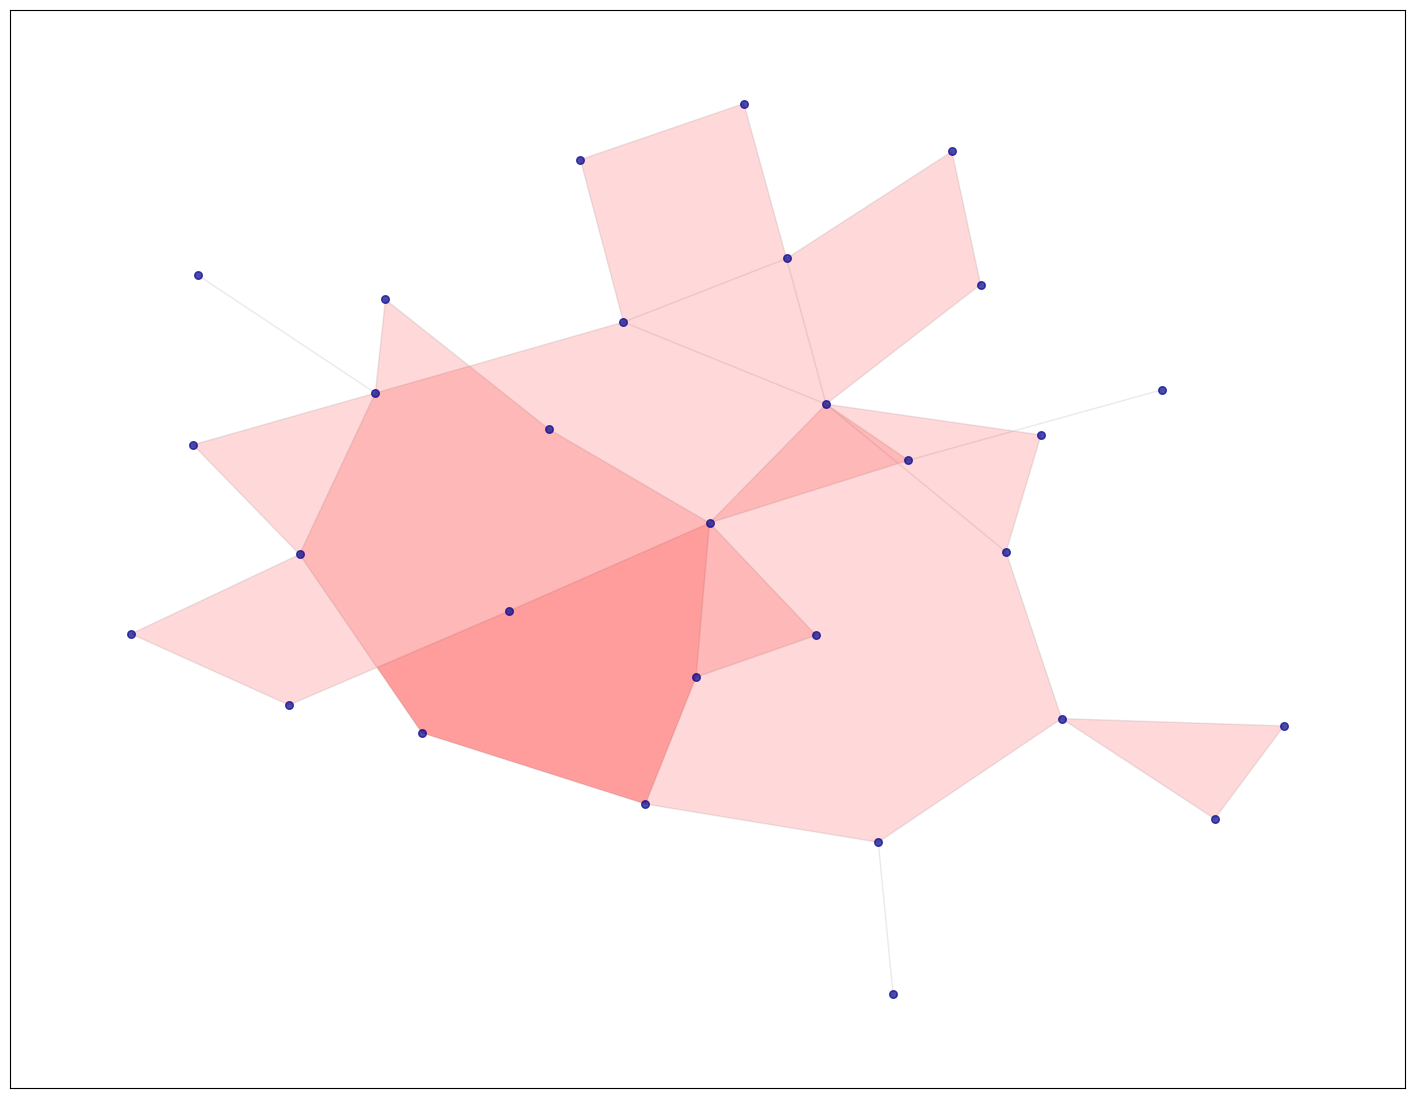

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Setup figure and establish a planar layout
plt.figure(figsize=(18, 14))
ax = plt.gca() # Get current axes to add patches

pos = nx.kamada_kawai_layout(G)

# --- Draw Context Graph Layer ---
# Background Edges (Light gray, unshaded)
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color='#DCDCDC', 
                       width=1.0, alpha=0.6, ax=ax)

# Background Nodes (Dark blue, small)
nx.draw_networkx_nodes(G, pos, node_size=30, node_color='#00008B', 
                       alpha=0.7, ax=ax)

num_shaded = 0
for i, loop_nodes in enumerate(cycles):
    # A cycle basis must have at least 3 nodes to enclose an area
    if len(loop_nodes) < 3: continue 

    # 1. Extract the geometric (x,y) vertices for the cycle from our layout 'pos'
    # We use numpy to ensure coordinates are formatted correctly for Polygon
    polygon_vertices = np.array([pos[node] for node in loop_nodes])

    shaded_area = patches.Polygon(polygon_vertices, 
                                  closed=True, 
                                  facecolor='red', 
                                  alpha=0.15, 
                                  edgecolor=None)

    # 3. Add the geometry to the plot axes
    ax.add_patch(shaded_area)
    num_shaded += 1
# This final command displays the interactive window or renders the image
plt.show()


In [4]:
# --- 5. RUN POWER FLOW & EXTRACT ELECTRICAL STATE ---
print("\n--- Running Power Flow ---")
pp.runpp(net)
print(f"Converged: {net['converged']}")

base_mva = net.sn_mva

# Initialize vectors to exactly match the N rows of M_NE
V_mag = np.zeros(num_nodes)
V_angle_rad = np.zeros(num_nodes)
P_inj_pu = np.zeros(num_nodes)
Q_inj_pu = np.zeros(num_nodes)

# Extract values explicitly mapped to our sorted node order
for i, node in enumerate(nodes):
    # Voltage Magnitude (already per-unit)
    V_mag[i] = net.res_bus.at[node, 'vm_pu']
    
    # Voltage Angle (Convert degrees to radians)
    V_angle_rad[i] = np.radians(net.res_bus.at[node, 'va_degree'])
    
    # Power Injection (Convert MW/MVar to p.u. AND invert sign for injection)
    P_inj_pu[i] = -net.res_bus.at[node, 'p_mw'] / base_mva
    Q_inj_pu[i] = -net.res_bus.at[node, 'q_mvar'] / base_mva

# Extract the Admittance Matrix (Ybus)
# (Pandapower's internal PYPOWER engine generates this during runpp)
Ybus_sparse = net["_ppc"]["internal"]["Ybus"]
Ybus_matrix = Ybus_sparse.toarray()

print("\n--- Extracted Electrical Vectors & Matrices ---")
print(f"Ybus Matrix Shape: {Ybus_matrix.shape} (Complex)")
print(f"V_mag Shape:       {V_mag.shape}")
print(f"V_angle_rad Shape: {V_angle_rad.shape}")
print(f"P_inj_pu Shape:    {P_inj_pu.shape}")
print(f"Q_inj_pu Shape:    {Q_inj_pu.shape}")

# Optional: Form the complex Voltage vector
V_complex = V_mag * np.exp(1j * V_angle_rad)

S_inj_pu = P_inj_pu + 1j * Q_inj_pu


--- Running Power Flow ---
Converged: True

--- Extracted Electrical Vectors & Matrices ---
Ybus Matrix Shape: (30, 30) (Complex)
V_mag Shape:       (30,)
V_angle_rad Shape: (30,)
P_inj_pu Shape:    (30,)
Q_inj_pu Shape:    (30,)


In [5]:
# --- 6. BUILD THE PRIMITIVE ADMITTANCE MATRIX (Y_prim) ---
print("\n--- Building Primitive Y Matrix (Y_prim) ---")

# Y_prim is an E x E diagonal matrix containing the series admittance of each branch.
Y_prim_matrix = np.zeros((num_edges, num_edges), dtype=complex)

# Extract the branch matrix from Pandapower's internal PYPOWER engine.
# This contains the per-unit Resistance (R) and Reactance (X) for all lines/transformers.
ppc_branch = net["_ppc"]["branch"]

# Dictionary to hold the equivalent series admittance for each topological edge
branch_admittances = {}

for row in ppc_branch:
    f_bus = int(row[0].real) # From Bus
    t_bus = int(row[1].real) # To Bus
    r_pu = row[2].real       # Resistance (p.u.)
    x_pu = row[3].real       # Reactance (p.u.)
    
    # Calculate Series Admittance: y = 1 / (R + jX)
    z_series = r_pu + 1j * x_pu
    y_series = 1 / z_series if z_series != 0 else 0j
    
    # Standardize the tuple so smaller node ID is first (matching our sorted 'edges' list)
    edge_tuple = (min(f_bus, t_bus), max(f_bus, t_bus))
    
    # Because we used multi=False to build the topology, we MUST sum the 
    # admittances of parallel lines to maintain electrical equivalence.
    if edge_tuple in branch_admittances:
        branch_admittances[edge_tuple] += y_series
    else:
        branch_admittances[edge_tuple] = y_series

# Populate the diagonal Y_prim matrix perfectly aligned with our M_NE and M_EC matrices
for e_idx, edge in enumerate(edges):
    # Retrieve the calculated admittance. Defaults to 0j if something goes wrong.
    Y_prim_matrix[e_idx, e_idx] = branch_admittances.get(edge, 0j)

print(f"Y_prim Matrix Shape: {Y_prim_matrix.shape} (Complex Diagonal)")
print(f"First element Y_prim[0,0] (Edge {edges[0]}): {Y_prim_matrix[0,0]:.4f}")


--- Building Primitive Y Matrix (Y_prim) ---
Y_prim Matrix Shape: (41, 41) (Complex Diagonal)
First element Y_prim[0,0] (Edge (np.int64(0), np.int64(1))): 5.0000-15.0000j


In general cases, $Y_\text{bus} \neq A Y_\text{primitive} A^\top$, where $A$ is node-edge-incidence matrix

In [6]:
# --- 7. VERIFYING Y_bus vs TOPOLOGICAL MATH ---
print("\n--- Verifying Y_bus against Topology ---")

# Calculate the topological Ybus
# Dimensions: (N x E) @ (E x E) @ (E x N) -> (N x N)
Ybus_calculated = M_NE @ Y_prim_matrix @ M_NE.T

# Calculate the absolute difference between Pandapower's Ybus and our calculated one
diff_matrix = np.abs(Ybus_matrix - Ybus_calculated)

# Isolate the differences on the off-diagonals vs the main diagonal
off_diag_diff = diff_matrix - np.diag(np.diagonal(diff_matrix))
diag_diff = np.diagonal(diff_matrix)

print(f"Max error on OFF-diagonals (Transmission lines): {np.max(off_diag_diff):.6f}")
print(f"Max error on MAIN diagonal (Bus self-admittance): {np.max(diag_diff):.6f}")



--- Verifying Y_bus against Topology ---
Max error on OFF-diagonals (Transmission lines): 0.000000
Max error on MAIN diagonal (Bus self-admittance): 0.045000


## Hodge analysis

### Voltage flow is curl-free --- KVL

In [7]:
# --- 9. KIRCHHOFF'S VOLTAGE LAW (KVL) VIA TOPOLOGY ---
print("\n--- Computing Edge Voltages & KVL ---")

# 1. Calculate the voltage drop across every single transmission line
# M_NE.T is (E x N) @ V_complex (N x 1) -> Delta_V is (E x 1)
Delta_V = M_NE.T @ V_complex

print(f"Voltage Drop Vector (Delta_V) Shape: {Delta_V.shape}")

# 2. Sum the voltage drops around every fundamental cycle
# M_EC.T is (C x E) @ Delta_V (E x 1) -> Loop_V is (C x 1)
Loop_V = M_EC.T @ Delta_V

print(f"Loop Voltage Vector Shape:           {Loop_V.shape}")

# 3. Verify KVL (The sum of voltage drops around any closed loop MUST be zero)
is_kvl_satisfied = np.allclose(Loop_V, 0)
print(f"\nIs Kirchhoff's Voltage Law satisfied? {is_kvl_satisfied}")

# Print the maximum floating-point deviation just to see the numerical precision
max_error = np.max(np.abs(Loop_V))
norm_error = np.linalg.norm(Loop_V)
print(f"Maximum deviation from absolute zero: {max_error:.2e}")
print(f"Norm of Loop Voltage Vector: {norm_error:.2e}")


--- Computing Edge Voltages & KVL ---
Voltage Drop Vector (Delta_V) Shape: (41,)
Loop Voltage Vector Shape:           (12,)

Is Kirchhoff's Voltage Law satisfied? True
Maximum deviation from absolute zero: 3.47e-18
Norm of Loop Voltage Vector: 3.47e-18


#### The difficulty is about extracting the correct edge-admittance matrix. 

Let's build it from the node-bus admittance matrix by 

In [8]:
# --- 18. DERIVING EDGE ADMITTANCE FROM Y_bus ---
print("\n--- Constructing Edge Matrix from Nodal Matrix ---")

# Initialize the E x E diagonal matrix
# num_edges is the length of our 'edges' list from the topology step
Y_edge_derived = np.zeros((num_edges, num_edges), dtype=complex)

for e_idx, (u, v) in enumerate(edges):
    # 1. Map the bus IDs to our matrix row/column indices
    u_idx = node_idx_map[u]
    v_idx = node_idx_map[v]
    
    # 2. Extract the off-diagonal entry
    # Mathematical Rule: Y_bus[i, j] = -y_edge
    # So: y_edge = -Y_bus[i, j]
    y_ij = -Ybus_matrix[u_idx, v_idx]
    
    # 3. Place it on the diagonal of the edge matrix
    Y_edge_derived[e_idx, e_idx] = y_ij

print(f"Derived Edge Matrix Shape: {Y_edge_derived.shape}")
 

# Note: This derived matrix is 'equivalent' because it inherently includes 
# the transformer tap ratios (a) that were baked into the Y_bus off-diagonals.


--- Constructing Edge Matrix from Nodal Matrix ---
Derived Edge Matrix Shape: (41, 41)


### idea 1: calculate voltages and currents on the edges --- requiring the correct edge-admittance matrix

In [9]:
Delta_I = Y_edge_derived @ Delta_V
# KCL 
Node_Injection = M_NE @ Delta_I

S_inj_pu_edge_based = V_complex * np.conj(Node_Injection)

print(f"Node Injection from KCL (first 10): {S_inj_pu_edge_based[:10]}")
print(f"Node Injection from Power Flow (first 10): {S_inj_pu[:10]}")
 


Node Injection from KCL (first 10): [ 2.59738031e-01+1.50151577e-02j  3.92700000e-01+2.37989821e-01j
 -2.40000000e-02-2.33439104e-03j -7.60000000e-02-6.39417720e-03j
 -1.49047522e-12+1.63105607e-02j  1.76043809e-11+1.89417428e-02j
 -2.28000000e-01-9.96422344e-02j -3.00000000e-01-2.90772021e-01j
  1.07050308e-11+5.47528622e-12j -5.80000000e-02-2.00000000e-02j]
Node Injection from Power Flow (first 10): [ 0.25973803-0.00998484j  0.3927    +0.19298982j -0.024     -0.012j
 -0.076     -0.016j       0.        +0.00183373j -0.        +0.j
 -0.228     -0.109j      -0.3       -0.3j        -0.        +0.j
 -0.058     -0.02j      ]


### This equation is correct, iff the edge-admittance matrix is correct

$$
    I = B_1 \Delta_i \quad S = U I^\star
$$

In [10]:
# 3. Calculate Nodal Power Injections (S = V * I*)
# Multiply the nodal voltage by the conjugate of the net nodal current
S_node_calc = V_complex * np.conj(Node_Injection)

# Extract Calculated P and Q
P_calc = np.real(S_node_calc)
Q_calc = np.imag(S_node_calc)

# 4. VERIFICATION against Pandapower's vectors
P_diff = np.abs(P_calc - P_inj_pu)
Q_diff = np.abs(Q_calc - Q_inj_pu)

print(f"Error in Real Power (P):     {np.linalg.norm(P_diff):.6f} p.u.")
print(f"Error in Reactive Power (Q): {np.linalg.norm(Q_diff):.6f} p.u.")


Error in Real Power (P):     0.000000 p.u.
Error in Reactive Power (Q): 0.061481 p.u.


In [11]:
# --- 19. EXTRACTING BRANCH CURRENTS FROM SOLVER ---
print("\n--- Extracting Complex Branch Currents ---")

# Initialize the complex current vector (E x 1)
I_branch_solver = np.zeros(num_edges, dtype=complex)

# We need the base values for conversion
base_mva = net.sn_mva

for e_idx, (u, v) in enumerate(edges):
    # 1. Find the branch in Pandapower results (Line or Transformer)
    # Search in lines
    line_mask = ((net.line.from_bus == u) & (net.line.to_bus == v)) | \
                ((net.line.from_bus == v) & (net.line.to_bus == u))
    
    # Search in transformers
    trafo_mask = ((net.trafo.hv_bus == u) & (net.trafo.lv_bus == v)) | \
                 ((net.trafo.hv_bus == v) & (net.trafo.lv_bus == u))

    if any(line_mask):
        res = net.res_line.loc[line_mask].iloc[0]
        # Check if our edge (u,v) matches the solver's (from,to)
        is_forward = (net.line.loc[line_mask].iloc[0].from_bus == u)
        p_mw = res.p_from_mw if is_forward else res.p_to_mw
        q_mvar = res.q_from_mvar if is_forward else res.q_to_mvar
        v_bus = u # The bus we are measuring 'from'
    elif any(trafo_mask):
        res = net.res_trafo.loc[trafo_mask].iloc[0]
        is_forward = (net.trafo.loc[trafo_mask].iloc[0].hv_bus == u)
        p_mw = res.p_hv_mw if is_forward else res.p_lv_mw
        q_mvar = res.q_hv_mvar if is_forward else res.q_lv_mvar
        v_bus = u
    else:
        continue

    # 2. Calculate Complex Power S in per-unit
    S_pu = (p_mw + 1j * q_mvar) / base_mva
    
    # 3. Get Complex Voltage at the 'from' bus
    V_at_bus = V_complex[node_idx_map[v_bus]]
    
    # 4. Calculate Complex Current: I = (S / V)*
    # This is the actual current injection into the branch from bus u
    I_branch_solver[e_idx] = np.conj(S_pu / V_at_bus)

print(f"Extracted Current Vector Shape: {I_branch_solver.shape}")
print(f"Current on first edge ({edges[0]}): {I_branch_solver[0]:.4f} p.u.")


--- Extracting Complex Branch Currents ---
Extracted Current Vector Shape: (41,)
Current on first edge ((np.int64(0), np.int64(1))): 0.1089+0.0509j p.u.



### idea 2: This equation is wrong --- calculating also power flows on the edges  
Use another way to compute the power flow injected to buses:

$$
    \Delta_S = \Delta_V \odot \Delta_I^\star
$$
where $\odot$ is the Hadamard product or elementwise-product. 

We are computing the **EDGE power flow**.

Then, the injected flow 

$$ 
    S = B_1 \Delta_S
$$

We then examine the $P$ and $Q$ values from this computation with the Pp solver. 

In [12]:
# --- 11. TESTING THE HADAMARD EDGE POWER FORMULA ---
print("\n--- Testing Edge Power Formula ---")

# 1. Compute Edge Power Flow using Hadamard (element-wise) product
# We use np.conj() on Delta_I because AC Power S = V * I*
Delta_S = Delta_V * np.conj(Delta_I)

# 2. Map Edge Power to Nodal Injections using the incidence matrix (B1 / M_NE)
S_proposed = M_NE @ Delta_S

P_proposed = np.real(S_proposed)
Q_proposed = np.imag(S_proposed)

# 3. Examine against Pandapower's exact solver values
P_error_proposed = np.abs(P_proposed - P_inj_pu)
Q_error_proposed = np.abs(Q_proposed - Q_inj_pu)

print(f"Max Error in Real Power (P):     {np.max(P_error_proposed):.4f} p.u.")
print(f"Max Error in Reactive Power (Q): {np.max(Q_error_proposed):.4f} p.u.")

# Let's look at Bus 0 specifically
print(f"\nBus 0 P Injection (Pandapower):  {P_inj_pu[0]:.4f}")
print(f"Bus 0 P Injection (Your Formula):{P_proposed[0]:.4f}")


--- Testing Edge Power Formula ---
Max Error in Real Power (P):     0.3872 p.u.
Max Error in Reactive Power (Q): 0.3977 p.u.

Bus 0 P Injection (Pandapower):  0.2597
Bus 0 P Injection (Your Formula):0.0015


### Idea 3

1. Since (complex) voltage flow is curl-free, we can build a purely topology Hodge Laplacian, which further allows using Hodge Laplaican based methods to infer the whole voltage flow. 
   1. from the voltage flow, we can get voltage node signal, then compute the current node signal based on the node-admittance matrix --- this way, we bypass the challenges posed by the non-diagonal edge-admittance matrix

### Only use the KVL, we can infer the full voltage flows ---- only calculating the voltages on the edges
from the voltage flow, we can get voltage node signal

#### This step --- from the voltage edge flow to voltage node signal, shall be fixed by taking into account the reference bus

##### This is correct iff $I = Y_{\text{bus}} U$ on the node space

In [13]:
from scipy.linalg import pinv

# --- 17. RECONSTRUCTING V_complex FROM Delta_V ---
print("\n--- Reconstructing Nodal Voltages from Edge Drops ---")

# 1. Identify our reference (Slack Bus)
# We need one absolute value to 'anchor' the integration.
slack_bus_idx = 0 
v_slack = V_complex[slack_bus_idx]

# 2. Reduce the system
# We remove the column corresponding to the slack bus from M_NE.T
# This makes the matrix full rank (N-1)
M_reduced_T = np.delete(M_NE.T, slack_bus_idx, axis=1)

# 3. Adjust Delta_V for the slack bus contribution
# In the equation: Delta_V = M_reduced_T * V_rest + M_slack_column * v_slack
# So: (Delta_V - M_slack_column * v_slack) = M_reduced_T * V_rest
m_slack_col = M_NE.T[:, slack_bus_idx]
target = Delta_V - (m_slack_col * v_slack)

# 4. Solve for the remaining voltages (V_rest)
# Using Least Squares (lstsq) handles the overdetermined meshed system
v_rest_reconstructed, residuals, rank, s = np.linalg.lstsq(M_reduced_T, target, rcond=None)

# 5. Reassemble the full V vector
V_reconstructed = np.insert(v_rest_reconstructed, slack_bus_idx, v_slack)

# --- VERIFICATION ---
v_error = np.abs(V_complex - V_reconstructed)
print(f"Max reconstruction error: {np.max(v_error):.2e} p.u.")

if np.allclose(V_complex, V_reconstructed):
    print("SUCCESS: V_complex perfectly reconstructed from Delta_V!")


--- Reconstructing Nodal Voltages from Edge Drops ---
Max reconstruction error: 2.00e-15 p.u.
SUCCESS: V_complex perfectly reconstructed from Delta_V!


In [14]:

I_node = Ybus_matrix @ V_reconstructed

S_node = V_reconstructed * np.conj(I_node)

np.linalg.norm(S_inj_pu - S_node) / np.linalg.norm(S_inj_pu)

np.float64(0.0017851034723764324)

### Try some Hodge Laplacian based solvers 

In [15]:
L_d = M_NE.T @ M_NE
L_u = M_EC @ M_EC.T
L = L_d + L_u

### simplicial Fourier analysis of voltages

In [16]:
from scipy.linalg import eigh
eigenvalues_d, eigenvectors_d = eigh(L_d)
tol = 1e-10
nonzero_mask = eigenvalues_d > tol
grad_eigenvalues = eigenvalues_d[nonzero_mask]
grad_eigenbasis = eigenvectors_d[:, nonzero_mask]


eigenvalues_u, eigenvectors_u = eigh(L_u)
tol = 1e-10
nonzero_mask = eigenvalues_u > tol
curl_eigenvalues = eigenvalues_u[nonzero_mask]
curl_eigenbasis = eigenvectors_u[:, nonzero_mask]

In [17]:
Delta_V_ft_curl, Delta_V_ft_grad = curl_eigenbasis.T@Delta_V, grad_eigenbasis.T@Delta_V

In [18]:
P_grad = grad_eigenbasis@grad_eigenbasis.T 

In [19]:
Delta_V

array([ 2.62933238e-05+7.25161750e-03j,  1.72085957e-02+2.61141952e-02j,
        2.03614993e-02+2.34437039e-02j,  1.80872506e-02+2.47002653e-02j,
        2.75513251e-02+3.12431983e-02j,  3.17919691e-03+4.58112622e-03j,
        7.18982579e-03+7.79949443e-03j, -5.50159096e-03-4.26412419e-03j,
        1.55669299e-02+1.28045199e-02j,  6.10285542e-03+6.26158688e-03j,
        1.28855352e-02+7.18832494e-03j, -6.74273133e-03+1.27684972e-02j,
       -1.02746382e-02+1.94567577e-02j, -1.53037214e-03+4.30787436e-05j,
       -1.44159073e-02-7.14524620e-03j, -3.53190689e-03+6.68826045e-03j,
        0.00000000e+00+0.00000000e+00j,  7.54332368e-03-1.47611751e-04j,
        1.57417755e-02+7.47755658e-03j, -8.84568159e-03+2.49216580e-03j,
       -1.55503262e-02+1.22812045e-03j, -1.45543305e-02-5.21922561e-02j,
        9.22928649e-03+1.29014579e-02j,  5.68259359e-03+1.31094695e-02j,
        8.75902314e-03+1.86644758e-02j, -3.54669290e-03+2.08011514e-04j,
        1.27749798e-02+1.92165773e-02j, -2.01841421

### denoising over the edge space

In [20]:
# V_complex_meas = V_complex + 0.1 * (np.random.randn(*V_complex.shape)) # Add small noise
# V_complex_edge_setpoint = M_NE.T @ V_complex_meas


V_complex_edge_setpoint = Delta_V + 0.001 * (np.random.randn(*Delta_V.shape)) # Add small noise
H = P_grad
V_smoothed = H @ V_complex_edge_setpoint

error = np.linalg.norm(V_smoothed - Delta_V)/np.linalg.norm(Delta_V)
print(f"Error after smoothing: {error:.4f} p.u.")

Error after smoothing: 0.0424 p.u.


In [21]:
V_complex_edge_setpoint

array([ 0.00138578+7.25161750e-03j,  0.01441114+2.61141952e-02j,
        0.01849637+2.34437039e-02j,  0.01789141+2.47002653e-02j,
        0.02762278+3.12431983e-02j,  0.00327729+4.58112622e-03j,
        0.00709245+7.79949443e-03j, -0.00587439-4.26412419e-03j,
        0.01533326+1.28045199e-02j,  0.00462616+6.26158688e-03j,
        0.0128254 +7.18832494e-03j, -0.00744933+1.27684972e-02j,
       -0.01088631+1.94567577e-02j, -0.00179112+4.30787436e-05j,
       -0.01442276-7.14524620e-03j, -0.0035543 +6.68826045e-03j,
       -0.00152827+0.00000000e+00j,  0.009353  -1.47611751e-04j,
        0.01497262+7.47755658e-03j, -0.00842198+2.49216580e-03j,
       -0.01793859+1.22812045e-03j, -0.01475411-5.21922561e-02j,
        0.0095558 +1.29014579e-02j,  0.00516496+1.31094695e-02j,
        0.00901559+1.86644758e-02j, -0.00360739+2.08011514e-04j,
        0.01242559+1.92165773e-02j, -0.02054046-1.18069633e-02j,
        0.0010588 +1.27082887e-02j,  0.00420624+7.87532971e-03j,
       -0.00553108-1.2034

In [22]:
import random 

m_edge = int(0.8 * num_edges) # 20% of edges to keep as 'live' measurements
# 2. Pick random edge indices
random.seed(99) # New seed for edge sampling
sampled_edge_indices = random.sample(range(num_edges), m_edge)

# --- 27. DIRECT MASKING OF Delta_V ---
print("\n--- Zeroing out 80% of Edge Drops (Direct Masking) ---")

# Create a clean copy so we don't destroy your original ground-truth data
Delta_V_sampled = Delta_V.copy()

# Create a list of all indices that were NOT in our 20% sample
all_indices = set(range(num_edges))
non_sampled_indices = list(all_indices - set(sampled_edge_indices))

# Set the 'unobserved' values to zero
Delta_V_sampled[non_sampled_indices] = 0.0 + 0.0j


--- Zeroing out 80% of Edge Drops (Direct Masking) ---


In [23]:
H = P_grad
Delta_V_interpolated = H @ Delta_V_sampled

error = np.linalg.norm(Delta_V_interpolated - Delta_V)/np.linalg.norm(Delta_V)
print(f"Error after smoothing: {error:.4f} p.u.")

Error after smoothing: 0.3036 p.u.


In [24]:
Delta_V_interpolated

array([ 7.50081850e-04+2.85938474e-03j,  1.64585139e-02+2.32548104e-02j,
        1.81375471e-02+2.21171672e-02j,  5.26532116e-03+7.22154668e-03j,
        2.52600380e-02+2.82075731e-02j,  2.42911506e-03+1.72174148e-03j,
        7.12249093e-03+6.09040592e-03j, -8.40829017e-03-6.74095713e-03j,
        2.08322511e-02+2.00260666e-02j,  8.37534257e-04-9.59959802e-04j,
        1.47123888e-02+9.53854957e-03j, -7.60068526e-03+1.12438836e-02j,
       -1.19905461e-02+1.64075304e-02j,  2.12333520e-03+4.74352799e-03j,
       -1.25890536e-02-4.79502157e-03j, -4.38986082e-03+5.16364681e-03j,
       -9.19416527e-17-2.61729725e-16j,  6.76847849e-03-3.62321371e-03j,
        1.58400039e-02+7.35671571e-03j, -6.52953606e-03+1.33564450e-03j,
       -4.21339053e-03+1.79123198e-04j, -1.45543305e-02-5.21922561e-02j,
        8.00210503e-03+1.09173130e-02j,  3.22823066e-03+9.14117952e-03j,
        9.53386833e-03+2.21400778e-02j, -4.77387437e-03-1.77613345e-03j,
        1.26767514e-02+1.93374182e-02j, -3.58331601